# POMDP Candidate Selector

Notebook-first inspection of the first belief-limited attacker selector.

This is not a trained policy yet. It ranks VAE candidates using noisy attacker observations and profile/intent metadata, then compares that ranking to the full-state Monte Carlo selector when ranked-candidate artifacts are available.


## Imports


In [1]:
#Imports
from __future__ import annotations
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from convoy_sim.feasibility import Environment
from convoy_sim.pomdp_candidate_selector import (
    build_candidate_observation_rows,
    rank_candidate_observation_rows,
    write_belief_ranked_csv,
    write_belief_ranked_json,
)
from convoy_sim.profile_generation_viz import FIXED_X_LIMITS, apply_limits, combined_limits, simple_ship_polygons, style_ax
from convoy_sim.realism import get_attacker_observation_config
from experiments.evaluate_attack_candidate_pool import load_candidate_records
from scenarios.convoy_profiles import get_convoy_layout_profile

PROJECT_ROOT

METRIC_FIG_FACE = "lightgrey"
METRIC_AX_FACE = "lightgrey"
METRIC_GRID_COLOR = "lightgrey"


def style_metric_ax(ax, title: str, *, xlabel: str = "", ylabel: str = "", grid_axis: str = "y"):
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_facecolor(METRIC_AX_FACE)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis=grid_axis, color=METRIC_GRID_COLOR, alpha=0.45, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)


## Config


In [2]:
CANDIDATE_PATH = Path("data/attack_profiles/vae_candidates/mixed_curated70_random30_hit_candidates.jsonl")
FULL_STATE_RANKED_CSV = Path("results/runs/candidate_pool_eval/20260511_211859_vae_source_compare_mixed_70_30/ranked_candidates.csv")
CONVOY_PROFILE = "convoy_layout_1"
MAX_PROFILES = 1000
TOP_K = 25
SEED = 1945

OBSERVATION_PRESET = "good_contact"
OBS_CFG = get_attacker_observation_config(OBSERVATION_PRESET)
ENV = Environment(time_of_day="night", visibility_m=3500.0, sea_state=4)

OUTPUT_DIR = PROJECT_ROOT / "results" / "diag" / "pomdp_candidate_selector"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Build Belief-Limited Ranking


In [3]:
records_all = load_candidate_records(PROJECT_ROOT / CANDIDATE_PATH)
records = records_all[: int(MAX_PROFILES)] if MAX_PROFILES is not None else records_all
ships = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()

observation_rows = build_candidate_observation_rows(
    records,
    ships=ships,
    seed=int(SEED),
    env=ENV,
    observation_cfg=OBS_CFG,
)
ranked_rows = rank_candidate_observation_rows(observation_rows)

belief_df = pd.DataFrame(ranked_rows)
write_belief_ranked_csv(OUTPUT_DIR / "belief_ranked_candidates.csv", ranked_rows)
write_belief_ranked_json(OUTPUT_DIR / "top_belief_candidates.json", ranked_rows[: int(TOP_K)])
belief_df.head(10)


,profile_id,name,belief_score,u_pos_x,u_pos_y,estimated_range_m,estimated_bearing_rad,estimated_convoy_heading_rad,estimated_convoy_speed_mps,estimated_contact_count,...,spawn_region,approach_side,inside_convoy_envelope,spread_rad,launch_delay_s,salvo_interval_s,u_boat_initial_speed_mps,candidate_source_label,selector_method,belief_rank
0,VAE001218,vae_candidate_001218,0.921535,469.571960,-2328.467773,2286.420593,1.774422,0.006002,4.676153,41,...,inside_convoy_envelope,inside,True,0.051890,1.279724,2.961656,1.263105,vae_candidate_pool_v1,belief_limited_heuristic_v1,1
1,VAE000995,vae_candidate_000995,0.915292,551.371948,2318.941406,2258.969870,-1.789800,0.001166,5.598670,37,...,inside_convoy_envelope,inside,True,0.124146,1.799432,1.516157,1.814563,vae_candidate_pool_v1,belief_limited_heuristic_v1,2
2,VAE001061,vae_candidate_001061,0.910223,-699.750061,1907.180420,2011.705800,-1.229123,0.023040,5.270972,37,...,inside_convoy_envelope,inside,True,0.067182,2.034932,1.501374,1.295147,vae_candidate_pool_v1,belief_limited_heuristic_v1,3
3,VAE000435,vae_candidate_000435,0.909328,603.477539,3167.550049,3002.227107,-1.732674,0.033638,4.882548,36,...,inside_convoy_envelope,inside,True,0.072438,2.234018,1.506572,1.921293,vae_candidate_pool_v1,belief_limited_heuristic_v1,4
4,VAE001091,vae_candidate_001091,0.908928,261.502441,2069.897461,2096.827929,-1.698847,-0.013791,5.156583,37,...,inside_convoy_envelope,inside,True,0.093518,0.880318,2.317576,1.786740,vae_candidate_pool_v1,belief_limited_heuristic_v1,5
5,VAE000766,vae_candidate_000766,0.908141,-143.002197,-2080.208984,2222.979621,1.496577,0.042811,5.093311,35,...,inside_convoy_envelope,inside,True,0.098095,0.858272,2.094674,1.110730,vae_candidate_pool_v1,belief_limited_heuristic_v1,6
6,VAE001110,vae_candidate_001110,0.907024,-360.172180,-2530.086670,2580.190983,1.422846,0.041746,5.031553,36,...,inside_convoy_envelope,inside,True,0.048014,2.304520,2.568442,1.622840,vae_candidate_pool_v1,belief_limited_heuristic_v1,7
7,VAE000775,vae_candidate_000775,0.906571,632.506287,2150.013184,2208.824655,-1.859950,-0.013371,5.095053,33,...,inside_convoy_envelope,inside,True,0.061793,2.074244,2.413447,1.251240,vae_candidate_pool_v1,belief_limited_heuristic_v1,8
8,VAE000213,vae_candidate_000213,0.905744,-319.361511,-2152.106445,2064.678746,1.433554,0.033907,5.306163,39,...,inside_convoy_envelope,inside,True,0.054060,0.688713,1.886062,1.550213,vae_candidate_pool_v1,belief_limited_heuristic_v1,9
9,VAE000820,vae_candidate_000820,0.904930,1121.855103,-1983.941406,2401.060557,2.074440,0.009249,5.051133,35,...,inside_convoy_envelope,inside,True,0.082911,1.456425,2.344119,1.631629,vae_candidate_pool_v1,belief_limited_heuristic_v1,10


## Summary


In [4]:
summary = {
    "candidate_path": str(PROJECT_ROOT / CANDIDATE_PATH),
    "profiles_ranked": int(len(belief_df)),
    "top_k": int(TOP_K),
    "best_profile_id": str(belief_df.iloc[0]["profile_id"]) if len(belief_df) else "",
    "best_belief_score": float(belief_df.iloc[0]["belief_score"]) if len(belief_df) else np.nan,
    "mean_belief_score": float(belief_df["belief_score"].mean()) if len(belief_df) else np.nan,
    "observation_preset": OBSERVATION_PRESET,
    "observation_config": OBS_CFG.to_dict(),
}
(OUTPUT_DIR / "belief_summary.json").write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")
summary


{'candidate_path': '/Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/mixed_curated70_random30_hit_candidates.jsonl',
 'profiles_ranked': 1000,
 'top_k': 25,
 'best_profile_id': 'VAE001218',
 'best_belief_score': 0.9215345679978593,
 'mean_belief_score': 0.7059251269931501,
 'observation_preset': 'good_contact',
 'observation_config': {'bearing_sigma_rad': 0.025,
  'range_sigma_m': 80.0,
  'heading_sigma_rad': 0.035,
  'speed_sigma_mps': 0.3,
  'contact_count_sigma': 0.25,
  'formation_width_sigma_m': 100.0,
  'formation_depth_sigma_m': 120.0,
  'class_count_sigma': 0.5,
  'contact_detection_fraction': 0.85,
  'contact_detection_fraction_sigma': 0.05}}

## Belief Feature Diagnostics


In [5]:
display_cols = [
    "belief_rank",
    "profile_id",
    "belief_score",
    "estimated_range_m",
    "bearing_alignment_score",
    "aspect_score",
    "spread_score",
    "inside_score",
    "uncertainty_score",
    "spawn_region",
    "approach_side",
]
belief_df[display_cols].head(int(TOP_K))


,belief_rank,profile_id,belief_score,estimated_range_m,bearing_alignment_score,aspect_score,spread_score,inside_score,uncertainty_score,spawn_region,approach_side
0,1,VAE001218,0.921535,2286.420593,0.976402,0.980536,0.848460,1.0,0.073275,inside_convoy_envelope,inside
1,2,VAE000995,0.915292,2258.969870,0.998805,0.975860,0.836440,1.0,0.076795,inside_convoy_envelope,inside
2,3,VAE001061,0.910223,2011.705800,0.982857,0.949664,0.948409,1.0,0.077704,inside_convoy_envelope,inside
3,4,VAE000435,0.909328,3002.227107,0.985965,0.980948,0.971539,1.0,0.069400,inside_convoy_envelope,inside
4,5,VAE001091,0.908928,2096.827929,0.991829,0.993480,0.994881,1.0,0.076146,inside_convoy_envelope,inside
5,6,VAE000766,0.908141,2222.979621,0.997995,0.993160,0.984721,1.0,0.076445,inside_convoy_envelope,inside
6,7,VAE001110,0.907024,2580.190983,0.999993,0.982062,0.816831,1.0,0.075827,inside_convoy_envelope,inside
7,8,VAE000775,0.906571,2208.824655,0.966098,0.962213,0.918321,1.0,0.076695,inside_convoy_envelope,inside
8,9,VAE000213,0.905744,2064.678746,0.971075,0.985390,0.865198,1.0,0.075902,inside_convoy_envelope,inside
9,10,VAE000820,0.904930,2401.060557,0.969358,0.880256,0.997512,1.0,0.077063,inside_convoy_envelope,inside


In [6]:
component_cols = ["range_score", "bearing_alignment_score", "aspect_score", "spread_score", "contact_score", "inside_score", "uncertainty_score"]
component_summary = belief_df[component_cols].describe().T
component_summary.to_csv(OUTPUT_DIR / "belief_component_summary.csv")
component_summary


,count,mean,std,min,25%,50%,75%,max
range_score,1000.0,0.521963,0.353387,6.020935e-07,0.155009,0.571005,0.865401,1.000000
bearing_alignment_score,1000.0,0.913475,0.196683,1.937475e-05,0.947301,0.977392,0.994604,1.000000
aspect_score,1000.0,0.742633,0.286432,9.013733e-04,0.543446,0.877742,0.988847,1.000000
spread_score,1000.0,0.916401,0.073317,6.815283e-01,0.857698,0.934005,0.984318,1.000000
contact_score,1000.0,0.849286,0.049507,6.904762e-01,0.809524,0.857143,0.880952,1.000000
inside_score,1000.0,0.210000,0.407512,0.000000e+00,0.000000,0.000000,0.000000,1.000000
uncertainty_score,1000.0,0.075612,0.018896,6.374850e-02,0.068152,0.070262,0.074299,0.333129


## Compare To Full-State Ranking


In [7]:
if (PROJECT_ROOT / FULL_STATE_RANKED_CSV).exists():
    full_state_df = pd.read_csv(PROJECT_ROOT / FULL_STATE_RANKED_CSV)
    compare_df = belief_df.merge(
        full_state_df[["profile_id", "rank", "attacker_score", "expected_loss", "expected_hits", "expected_unique_ships_hit", "value_lost"]],
        on="profile_id",
        how="left",
        suffixes=("_belief", "_full_state"),
    )
    compare_df = compare_df.rename(columns={"rank": "full_state_rank"})
    compare_df["in_full_state_top_k"] = compare_df["full_state_rank"].le(int(TOP_K))
    compare_df["in_belief_top_k"] = compare_df["belief_rank"].le(int(TOP_K))
    overlap = int((compare_df["in_full_state_top_k"] & compare_df["in_belief_top_k"]).sum())
    comparison_summary = {
        "belief_top_k": int(TOP_K),
        "full_state_top_k": int(TOP_K),
        "top_k_overlap": overlap,
        "top_k_overlap_rate": float(overlap / max(int(TOP_K), 1)),
        "belief_best_profile_id": str(compare_df.sort_values("belief_rank").iloc[0]["profile_id"]),
        "full_state_best_profile_id": str(full_state_df.sort_values("rank").iloc[0]["profile_id"]),
    }
    compare_df.to_csv(OUTPUT_DIR / "belief_vs_full_state_ranked.csv", index=False)
    (OUTPUT_DIR / "belief_vs_full_state_summary.json").write_text(json.dumps(comparison_summary, indent=2) + "\n", encoding="utf-8")
else:
    full_state_df = pd.DataFrame()
    compare_df = belief_df.copy()
    comparison_summary = {"warning": f"Missing full-state ranked CSV: {PROJECT_ROOT / FULL_STATE_RANKED_CSV}"}
comparison_summary


{'belief_top_k': 25,
 'full_state_top_k': 25,
 'top_k_overlap': 0,
 'top_k_overlap_rate': 0.0,
 'belief_best_profile_id': 'VAE001218',
 'full_state_best_profile_id': 'VAE000124'}

In [8]:
if "full_state_rank" in compare_df.columns:
    compare_df[[
        "belief_rank",
        "full_state_rank",
        "profile_id",
        "belief_score",
        "expected_loss",
        "expected_hits",
        "expected_unique_ships_hit",
        "spawn_region",
    ]].sort_values("belief_rank").head(int(TOP_K))


## Plots


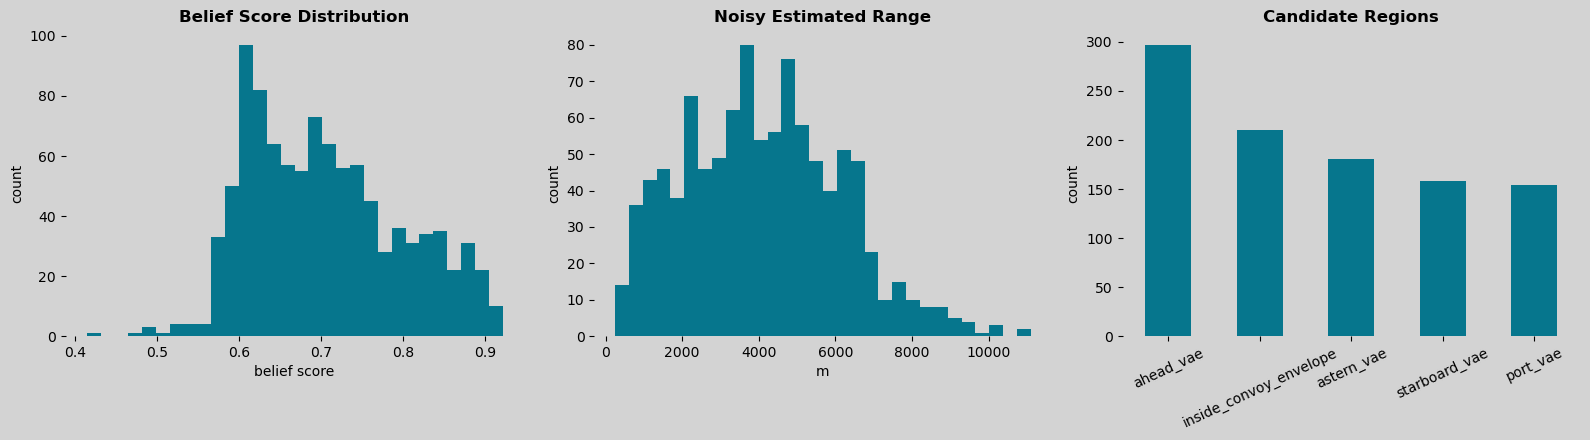

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor=METRIC_FIG_FACE)

belief_df["belief_score"].plot.hist(ax=axes[0], bins=30, color="#06768d", linewidth=0.6)
style_metric_ax(axes[0], "Belief Score Distribution", xlabel="belief score", ylabel="count")

belief_df["estimated_range_m"].plot.hist(ax=axes[1], bins=30, color="#06768d", linewidth=0.6)
style_metric_ax(axes[1], "Noisy Estimated Range", xlabel="m", ylabel="count")

belief_df["spawn_region"].value_counts().plot.bar(ax=axes[2], color="#06768d", linewidth=0.6)
style_metric_ax(axes[2], "Candidate Regions", ylabel="count")
axes[2].tick_params(axis="x", rotation=25)
fig.subplots_adjust(wspace=0.22)
plt.tight_layout()
plt.show()


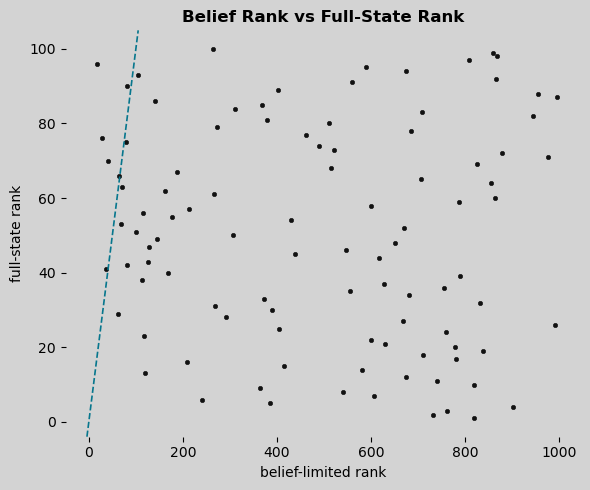

In [14]:
if "full_state_rank" in compare_df.columns:
    fig, ax = plt.subplots(figsize=(6, 5), facecolor=METRIC_FIG_FACE)
    plot_df = compare_df.dropna(subset=["full_state_rank"])
    ax.scatter(
        plot_df["belief_rank"],
        plot_df["full_state_rank"],
        s=10,
        alpha=1,
        color="#111111",
        linewidth=0.4,
    )
    ax.axline((1, 1), slope=1, color="#06768d", linestyle="--", linewidth=1.2)
    style_metric_ax(
        ax,
        "Belief Rank vs Full-State Rank",
        xlabel="belief-limited rank",
        ylabel="full-state rank",
        grid_axis="both",
    )
    plt.tight_layout()
    plt.show()


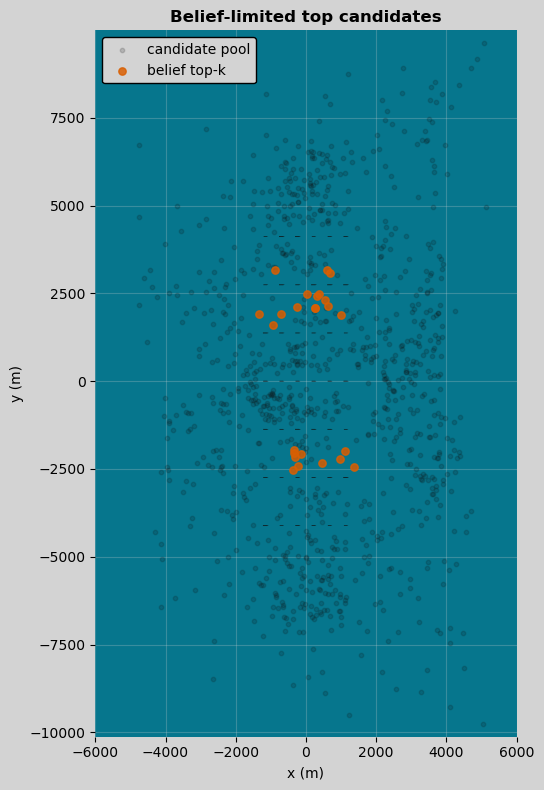

In [11]:
ship_xy = np.asarray([ship.position for ship in ships], dtype=float)
candidate_xy = belief_df[["u_pos_x", "u_pos_y"]].to_numpy(dtype=float) if {"u_pos_x", "u_pos_y"} <= set(belief_df.columns) else None
if candidate_xy is None:
    candidate_xy = np.asarray([record["profile"]["u_pos"] for record in records], dtype=float)
    belief_df["u_pos_x"] = candidate_xy[:, 0]
    belief_df["u_pos_y"] = candidate_xy[:, 1]
limits = combined_limits(ships, extra_points=candidate_xy, pad=350.0)

top_belief = belief_df.head(int(TOP_K)).copy()
fig, ax = plt.subplots(figsize=(10, 8), facecolor="lightgrey")
style_ax(ax, "Belief-limited top candidates")
simple_ship_polygons(ax, ships)
ax.scatter(candidate_xy[:, 0], candidate_xy[:, 1], c="#111111", s=10, alpha=0.16, label="candidate pool", zorder=2)
ax.scatter(top_belief["u_pos_x"], top_belief["u_pos_y"], c="#d95f02", s=28, alpha=0.85, label="belief top-k", zorder=3)
apply_limits(ax, limits, fixed_x_limits=FIXED_X_LIMITS)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.legend(frameon=True, facecolor="lightgrey", edgecolor="black", framealpha=1.0)
plt.tight_layout()
plt.show()


## Artifact Paths


In [12]:
{
    "belief_ranked_candidates_csv": str(OUTPUT_DIR / "belief_ranked_candidates.csv"),
    "top_belief_candidates_json": str(OUTPUT_DIR / "top_belief_candidates.json"),
    "belief_summary_json": str(OUTPUT_DIR / "belief_summary.json"),
    "belief_component_summary_csv": str(OUTPUT_DIR / "belief_component_summary.csv"),
    "belief_vs_full_state_ranked_csv": str(OUTPUT_DIR / "belief_vs_full_state_ranked.csv"),
    "belief_vs_full_state_summary_json": str(OUTPUT_DIR / "belief_vs_full_state_summary.json"),
}


{'belief_ranked_candidates_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_ranked_candidates.csv',
 'top_belief_candidates_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/top_belief_candidates.json',
 'belief_summary_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_summary.json',
 'belief_component_summary_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_component_summary.csv',
 'belief_vs_full_state_ranked_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_vs_full_state_ranked.csv',
 'belief_vs_full_state_summary_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_candidate_selector/belief_vs_full_state_summary.json'}